In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [16]:
dataset_path = "/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data"

print(os.listdir(dataset_path))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [17]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 49779 files belonging to 7 classes.
Using 39824 files for training.
Found 49779 files belonging to 7 classes.
Using 9955 files for validation.


In [18]:
class_names = train_ds.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


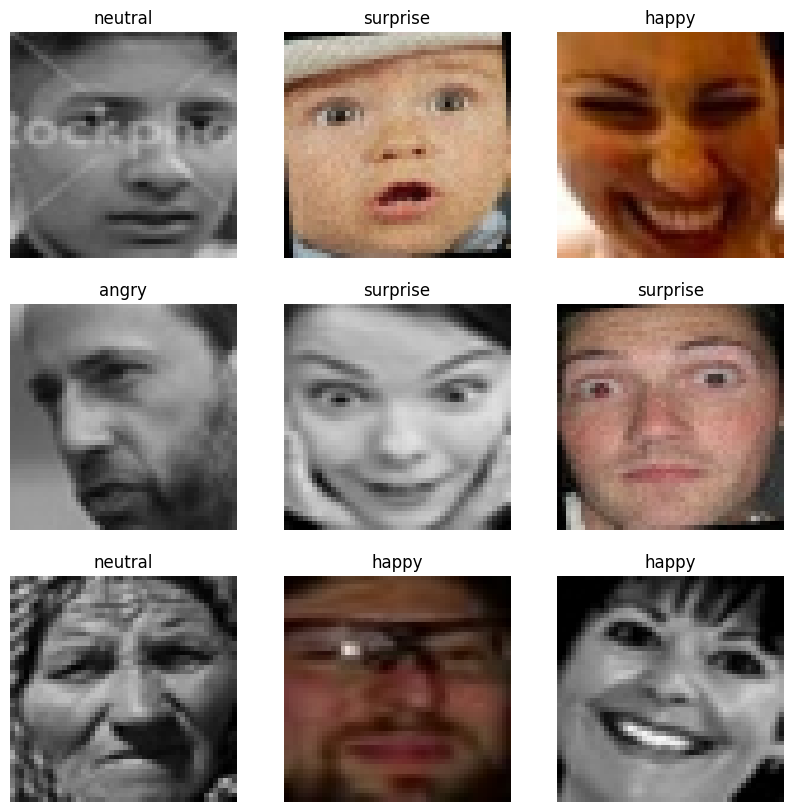

In [19]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [20]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [22]:
model = models.Sequential([
    
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(7, activation='softmax')
])

In [23]:
layers.Dense(7, activation='softmax')

<Dense name=dense_4, built=False>

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,423 (1.36 MB)

 Trainable params: 356,423 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.3223 - loss: 1.7138 - val_accuracy: 0.4860 - val_loss: 1.3834
Epoch 2/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.4906 - loss: 1.3456 - val_accuracy: 0.5353 - val_loss: 1.2411
Epoch 3/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 75s 61ms/step - accuracy: 0.5340 - loss: 1.2312 - val_accuracy: 0.5660 - val_loss: 1.1484
Epoch 4/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 75s 61ms/step - accuracy: 0.5601 - loss: 1.1639 - val_accuracy: 0.5677 - val_loss: 1.1393
Epoch 5/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.5793 - loss: 1.1080 - val_accuracy: 0.5779 - val_loss: 1.1237
Epoch 6/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.5950 - loss: 1.0669 - val_accuracy: 0.5776 - val_loss: 1.1162
Epoch 7/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 79s 64ms/step - accuracy: 0.6095 - loss: 1.0256 - val_accuracy: 0.5887 - val_loss: 1.0809
Epoch 8/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.6220 -

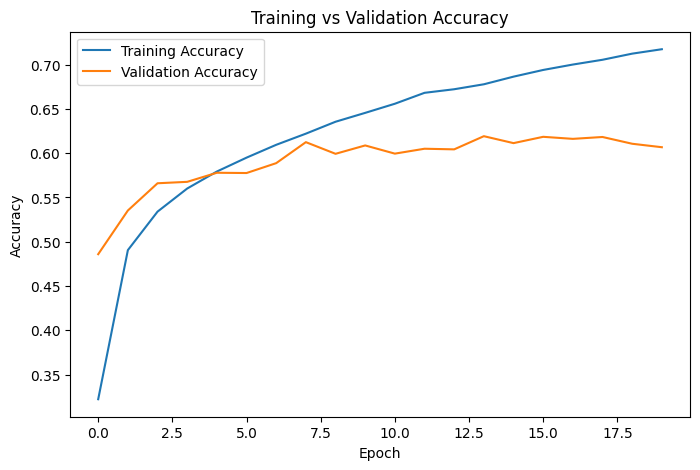

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()